# **Overview of the KLL Sketch**

The KLL sketch is a space-efficient algorithm used to estimate quantiles in a data stream. Instead of storing every data point, it maintains a compact summary that approximately preserves the order of the data. Here’s a brief overview of how it works:

---

## **1. Data Insertion**
Each new value $x$ is added to **level 0**:

$L_0 = L_0 \cup \{x\}$

If $|L_0| > C$ (capacity limit), the **compression** process begins.

---

## **2. Compression Process**
Each level $L_i$ has a capacity $C$. When a level exceeds $C$, we:

1. **Sort** the values:
   $L_i = \text{sorted}(L_i)$

2. **Downsample** (keep every second item):
   $L_{i+1} = L_{i+1} \cup \{ L_i[k] \text{ for } k=0,2,4,\dots \}$

3. **Clear** the current level:
   $L_i = \emptyset$

If $L_{i+1}$ exceeds capacity, repeat recursively.

---

## **3. Merging Two Sketches**
To merge two sketches $S_A$ and $S_B$:

1. Insert all elements of $S_B$ into $S_A$.
2. Perform standard **compression** recursively.

---

## **4. Quantile Approximation**
To estimate the quantile $q$, flatten and sort all levels:

$X = \bigcup_{i} L_i, \quad X = \text{sorted}(X)$

The estimated quantile is:

$Q(q) = X\left[\lfloor q \cdot |X| \rfloor \right]$

where $\lfloor \cdot \rfloor$ is the **floor function**.

---

## **5. CDF Approximation**
To estimate the **Cumulative Distribution Function (CDF)** at $x$:

$\hat{F}(x) = \frac{|\{ y \in X \mid y \leq x \}|}{|X|}$

This gives an approximate fraction of values $\leq x$.

---

## **6. Kolmogorov-Smirnov (KS) Distance Between Sketches**
Given two sketches $S_A$ and $S_B$, compute their CDFs $F_A(x)$ and $F_B(x)$ over $G$ grid points:

$D_{\text{KS}} = \max_{x \in G} | F_A(x) - F_B(x) |$

This measures the **maximum absolute difference** between the two distributions.

---

## **7. Key Complexity Properties**
- **Space Complexity**: $O(C \log n)$ (bounded by $C$ and depth of levels)
- **Update Complexity**: $O(\log n)$ (due to recursive compression)
- **Query Complexity**: $O(C \log n)$ (flattening levels)

In [8]:
import os
import random
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance
import math
import bisect

###############################################################################
# KLL Sketch Implementation (Weighted)
###############################################################################
class KLLSketchWeighted:
    """
    A 1D KLL sketch that stores (value, weight) pairs.
    Compression doubles the weight of kept items; merging unifies levels directly.
    """

    def __init__(self, capacity=50):
        """
        capacity: maximum size of each level before compressing
        """
        self.capacity = capacity
        # Each level is a list of (value, weight) pairs
        self.levels = [[]]
        self.total_weight = 0  # Sum of all item weights in the sketch

    def update(self, value):
        """
        Insert a single value by treating it as a batch of size 1.
        """
        self.batch_update([value])

    def batch_update(self, data):
        """
        Insert a batch of new values efficiently:
         1) Sort them once.
         2) Convert each to (value, weight=1).
         3) Insert them into level 0.
         4) Compress if needed.
        """
        if not data:
            return
        data_sorted = sorted(data)
        batch_pairs = [(val, 1) for val in data_sorted]
        self._merge_into_level(0, batch_pairs)
        self.total_weight += len(data)
        if len(self.levels[0]) > self.capacity:
            self._compress_level(0)

    def _merge_into_level(self, lvl, new_pairs):
        """
        Merge a batch of (value, weight) pairs into the given level.
        """
        self.levels[lvl].extend(new_pairs)

    def _compress_level(self, lvl):
        """
        Sort the level by value, discard ~50% of items, doubling the weight
        of the retained items. If next level is beyond capacity, recurse.
        """
        if lvl + 1 >= len(self.levels):
            self.levels.append([])

        self.levels[lvl].sort(key=lambda x: x[0])  # sort by value
        reservoir = self.levels[lvl]
        compressed = []
        for i in range(0, len(reservoir), 2):
            val, w = reservoir[i]
            compressed.append((val, w * 2))

        # Move compressed items to the next level
        self._merge_into_level(lvl + 1, compressed)
        # Clear current level
        reservoir.clear()

        # If next level is beyond capacity, compress further
        if len(self.levels[lvl + 1]) > self.capacity:
            self._compress_level(lvl + 1)

    def merge(self, other):
        """
        Merge `other` into `self` by unifying levels, avoiding repeated inserts.
        """
        max_levels = max(len(self.levels), len(other.levels))
        while len(self.levels) < max_levels:
            self.levels.append([])
        while len(other.levels) < max_levels:
            other.levels.append([])

        for i in range(max_levels):
            self.levels[i].extend(other.levels[i])
            if len(self.levels[i]) > self.capacity:
                self._compress_level(i)

        self.total_weight += other.total_weight

    def get_quantile(self, q):
        """
        Approximate the q-th quantile (0 <= q <= 1).
        Uses prefix sums over sorted (value, weight) pairs.
        """
        if self.total_weight == 0:
            return None
        all_pairs = self._flatten_levels()
        target_rank = q * self.total_weight
        running_sum = 0
        for val, w in all_pairs:
            running_sum += w
            if running_sum >= target_rank:
                return val
        return all_pairs[-1][0]  # fallback

    def get_cdf(self, values):
        """
        Approximate the CDF for each value in `values`.
        CDF(x) ~ (# of weighted items <= x) / total_weight
        """
        if self.total_weight == 0:
            return [0.0] * len(values)
        all_pairs = self._flatten_levels()

        results = []
        idx = 0
        running_sum = 0
        n_pairs = len(all_pairs)
        for v in values:
            while idx < n_pairs and all_pairs[idx][0] <= v:
                running_sum += all_pairs[idx][1]
                idx += 1
            results.append(running_sum / self.total_weight)
        return results

    def _flatten_levels(self):
        """
        Flatten all levels into a single list of (value, weight), then sort.
        """
        merged = []
        for lvl in self.levels:
            merged.extend(lvl)
        merged.sort(key=lambda x: x[0])
        return merged

    def __len__(self):
        # Just to see how many pairs at level[0] (for debugging)
        return len(self.levels[0])

###############################################################################
# KLL-based KS Distance (use total_weight, not total_count)
###############################################################################
def kll_kolmogorov_smirnov_distance(sketchA, sketchB, num_grid=50):
    """
    Compare two 1D KLL sketches with an approximate KS distance
    over 'num_grid' test points.
    """
    # Check empty
    if sketchA.total_weight == 0 or sketchB.total_weight == 0:
        return 0.0

    # Get min / max from both distributions
    minA = sketchA.get_quantile(0.0)
    maxA = sketchA.get_quantile(1.0)
    minB = sketchB.get_quantile(0.0)
    maxB = sketchB.get_quantile(1.0)
    global_min = min(minA, minB)
    global_max = max(maxA, maxB)

    if global_min == global_max:
        return 0.0

    # Evaluate each sketch's CDF over a linspace
    test_vals = np.linspace(global_min, global_max, num_grid)
    cdfA = sketchA.get_cdf(test_vals)
    cdfB = sketchB.get_cdf(test_vals)
    return max(abs(a - b) for (a, b) in zip(cdfA, cdfB))

###############################################################################
# The rest of your code below is unchanged, except referencing .total_weight
###############################################################################

args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 4000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "data-analysis/data",
    "hist_bins": 30,
    "num_seeds": 1,
    "kl_eps": 1e-12,
    "use_adaptive_gamma": True,
    "kll_capacity": 50,
    "kll_num_grid": 50
}

os.makedirs(args["output_dir"], exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

def build_2d_hist(embs_2d, bins=30):
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0],
        embs_2d[:, 1],
        bins=bins,
        density=False
    )
    hist = hist / hist.sum()
    return hist, xedges, yedges

def safe_prob(p, eps=1e-12):
    return np.maximum(p, eps)

def kl_divergence(p, q, kl_eps=1e-12):
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    return np.sum(p_ * np.log(p_ / q_))

def js_divergence(p, q, kl_eps=1e-12):
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    m_ = 0.5*(p_ + q_)
    return 0.5*kl_divergence(p_, m_, kl_eps=kl_eps) + 0.5*kl_divergence(q_, m_, kl_eps=kl_eps)

def bhattacharyya_distance(p, q, kl_eps=1e-12):
    bc = np.sum(np.sqrt(safe_prob(p, eps=kl_eps)*safe_prob(q, eps=kl_eps)))
    return -np.log(bc+1e-12)

def compute_2d_hist_distance(baseline_embs, new_embs, measure="js",
                             bins=30, kl_eps=1e-12):
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)
    hist_q_raw, _, _ = np.histogram2d(
        new_embs[:, 0],
        new_embs[:, 1],
        bins=[xedges, yedges],
        density=False
    )
    hist_q = hist_q_raw / hist_q_raw.sum()
    p = hist_p.flatten()
    q = hist_q.flatten()
    if measure == "kl":
        return kl_divergence(p, q, kl_eps=kl_eps)
    elif measure == "js":
        return js_divergence(p, q, kl_eps=kl_eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, kl_eps=kl_eps)
    else:
        raise ValueError(f"Unknown measure: {measure}")

def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2*np.dot(x, y.T)
    return np.exp(-gamma*dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m, n = len(X), len(Y)
    mmd2 = XX.sum()/(m**2) + YY.sum()/(n**2) - 2.0*XY.sum()/(m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i]-sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0/(2.0*median_dist2)

def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    from scipy.stats import wasserstein_distance
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum

###############################################################################
# 5) Main function for a single seed
###############################################################################
def run_experiment_single_seed(seed, args):
    set_seed(seed)
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name, dataset_config, dataset_split, text_col = dataset_info.values()
        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[:args["max_texts"]]

        half_point = len(texts)//2
        baseline_texts, drift_texts = texts[:half_point], texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device).eval()

            # 1) Build baseline embeddings
            baseline_embs = []
            for batch in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, batch, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # PCA -> 1D
            pca_1d = PCA(n_components=1).fit(baseline_embs)
            baseline_1d = pca_1d.transform(baseline_embs).flatten()

            # Build KLL Sketch Weighted
            baseline_sketch = KLLSketchWeighted(capacity=args["kll_capacity"])
            for val in baseline_1d:
                baseline_sketch.update(val)

            # Keep 2D for hist-based metrics
            pca_2d = PCA(n_components=args["pca_components"]).fit(baseline_embs)
            baseline_embs_2d = pca_2d.transform(baseline_embs)

            # MMD gamma
            gamma_val = auto_select_gamma(baseline_embs) if args["use_adaptive_gamma"] else 0.5

            distribution_measures = ["kl","js","bhattacharyya","mmd","wasserstein","kll_ks"]

            for measure_name in distribution_measures:
                for drift_strength in args["drift_strengths"]:
                    start_time = time.time()

                    # Introduce drift in the text
                    drifted_texts_mod = introduce_gradual_drift(drift_texts, drift_strength)
                    drift_embs = []
                    for batch in batch_generator(drifted_texts_mod, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, batch, device)
                        drift_embs.append(emb_b)
                    drift_embs = np.concatenate(drift_embs, axis=0)

                    # PCA -> 1D for drift
                    drift_1d = pca_1d.transform(drift_embs).flatten()
                    drift_sketch = KLLSketchWeighted(capacity=args["kll_capacity"])
                    for val in drift_1d:
                        drift_sketch.update(val)

                    # 2D for hist or MMD
                    drift_embs_2d = pca_2d.transform(drift_embs)

                    overhead_start = time.time()
                    if measure_name in ["kl","js","bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            drift_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                            kl_eps=args["kl_eps"]
                        )
                    elif measure_name == "mmd":
                        dist_val = compute_mmd(baseline_embs, drift_embs, gamma=gamma_val)
                    elif measure_name == "wasserstein":
                        dist_val = compute_wasserstein_1D_per_dim(baseline_embs_2d, drift_embs_2d)
                    elif measure_name == "kll_ks":
                        # Compare the two sketches
                        dist_val = kll_kolmogorov_smirnov_distance(
                            baseline_sketch, drift_sketch, num_grid=args["kll_num_grid"]
                        )
                    else:
                        dist_val = None

                    measure_overhead = time.time() - overhead_start
                    time_taken = time.time() - start_time

                    key = (dataset_name, model_name, measure_name, drift_strength)
                    results[key].append({
                        "dist_val": dist_val,
                        "time_taken": time_taken,
                        "measure_overhead": measure_overhead,
                        "seed": seed
                    })

    return results

###############################################################################
# 6) Collect data across multiple seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        for k, list_of_records in seed_results.items():
            all_results[k].extend(list_of_records)
    print("Data collection (all seeds) done!")
    return all_results

# Run everything
all_results = collect_data_multiple_seeds(args)


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
Data collection (all seeds) done!


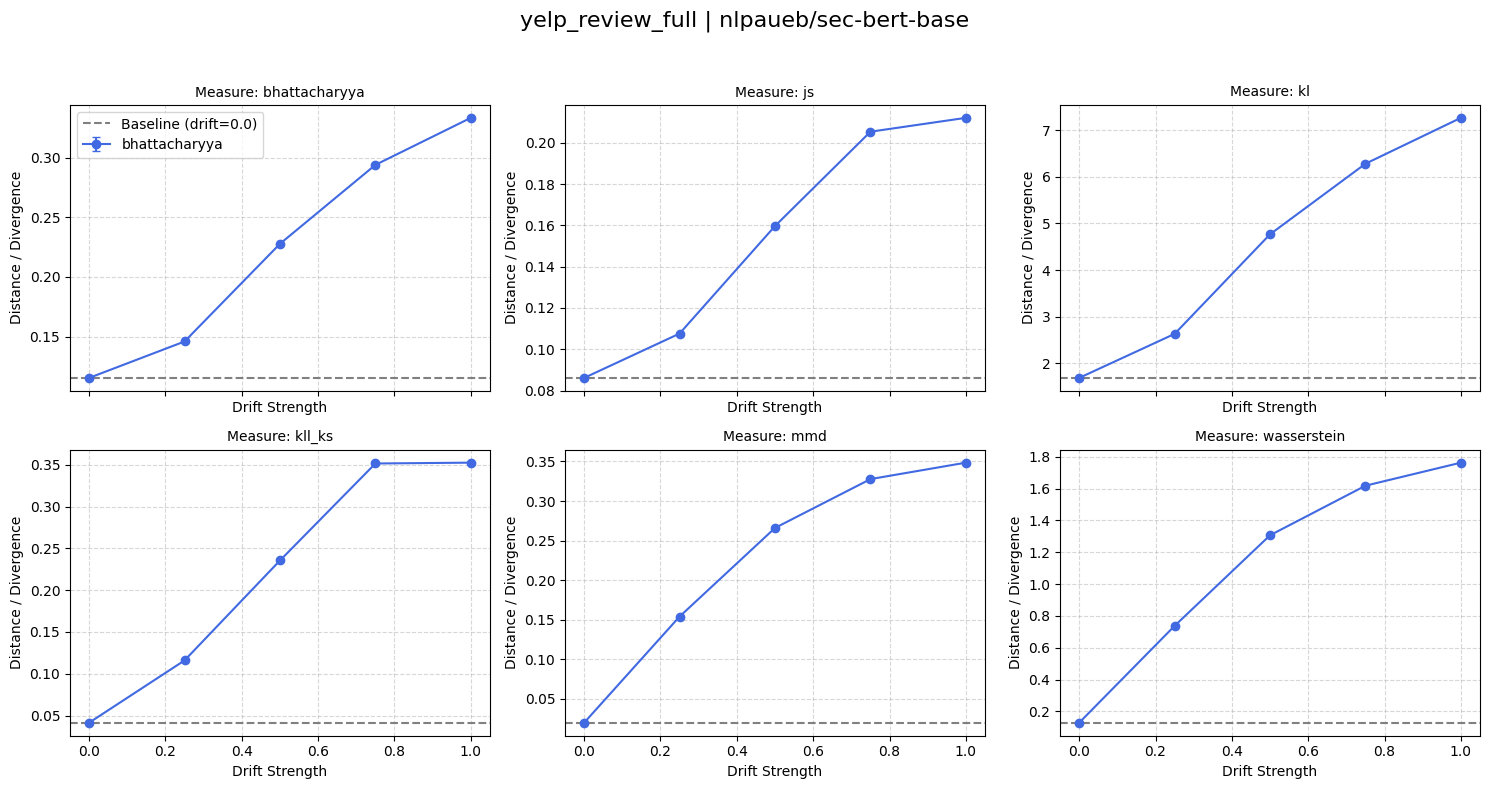

Saved figure: data-analysis/data/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


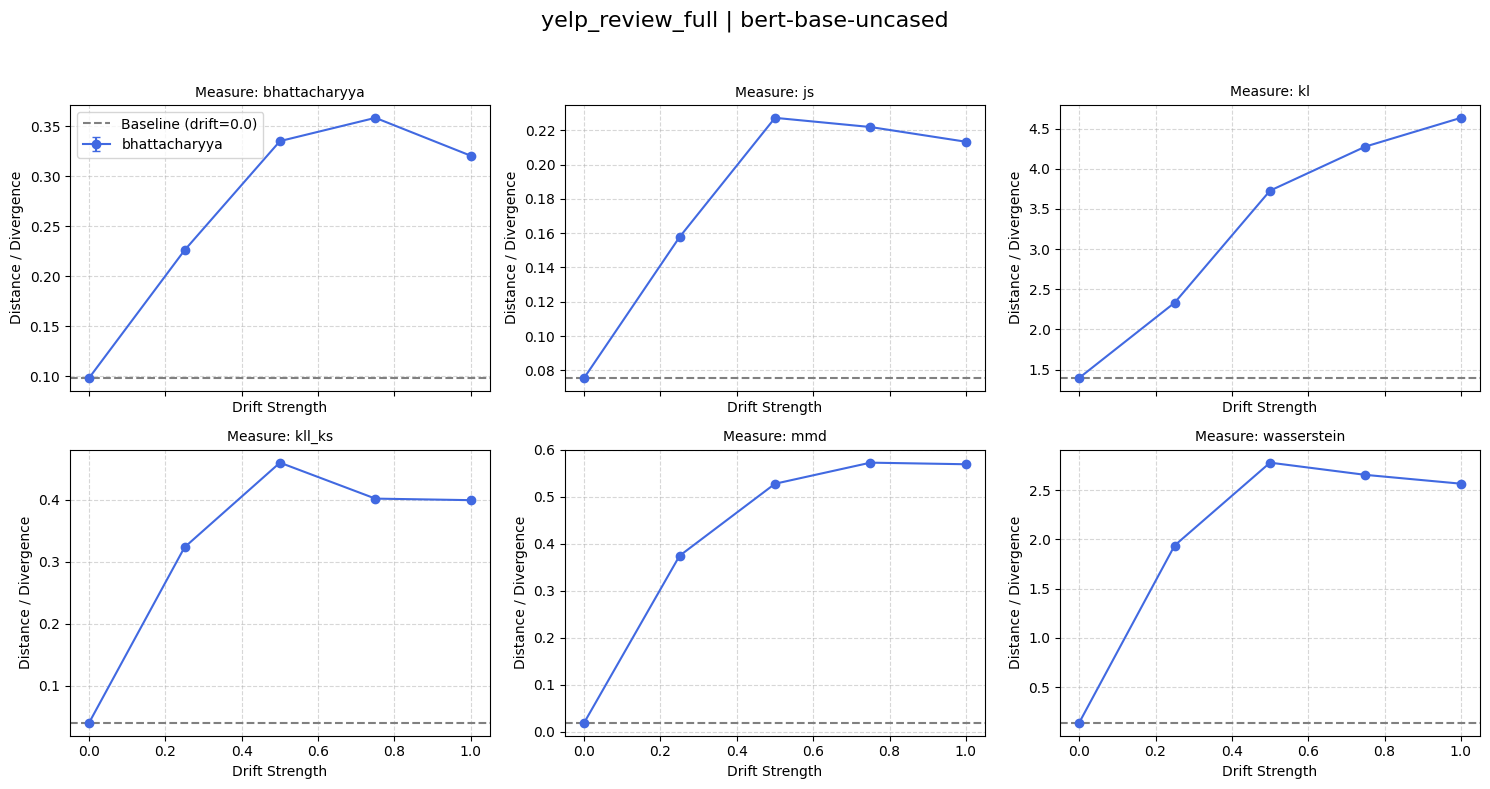

Saved figure: data-analysis/data/yelp_review_full_bert-base-uncased_distribution_measures.png


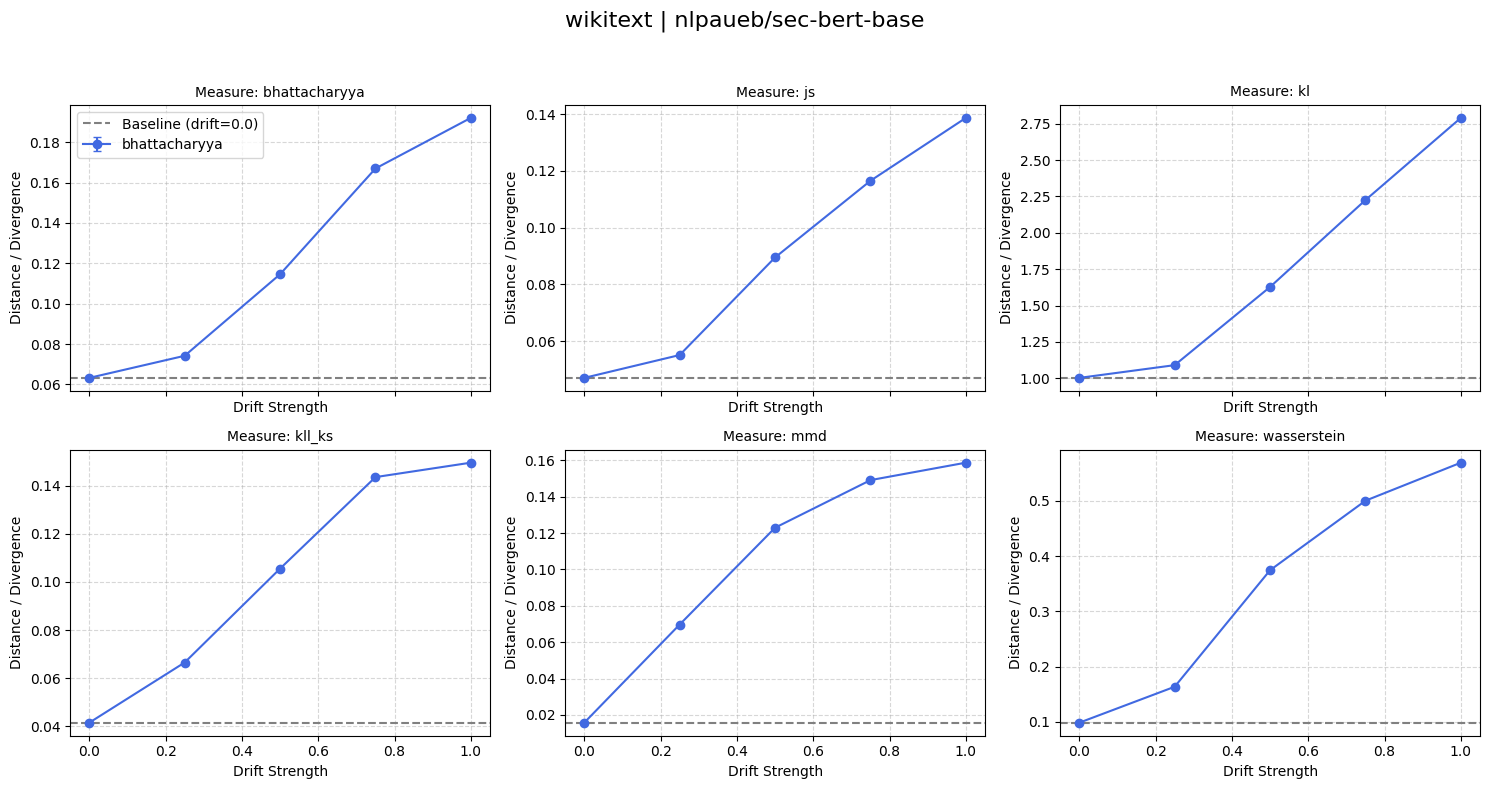

Saved figure: data-analysis/data/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


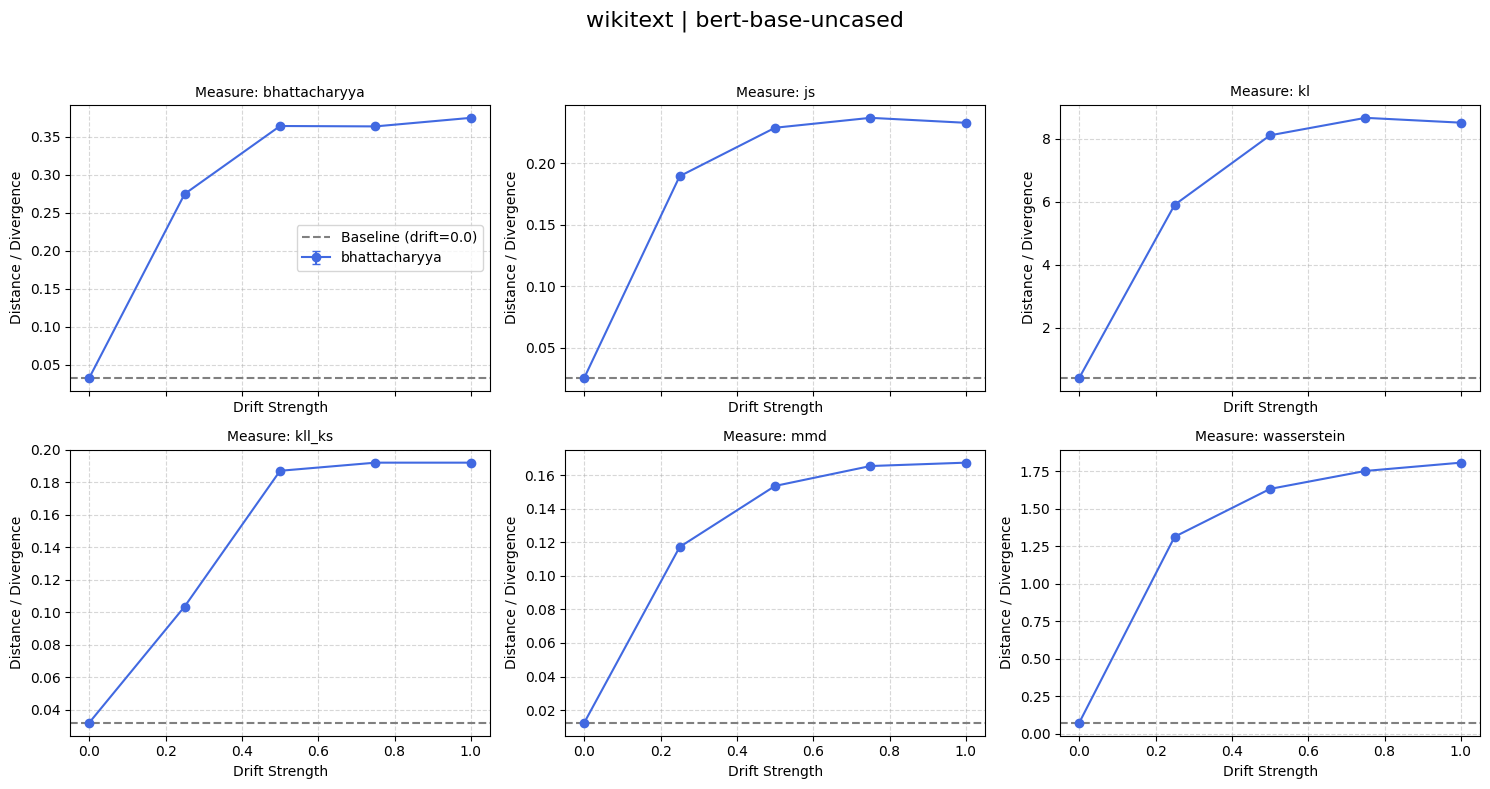

Saved figure: data-analysis/data/wikitext_bert-base-uncased_distribution_measures.png


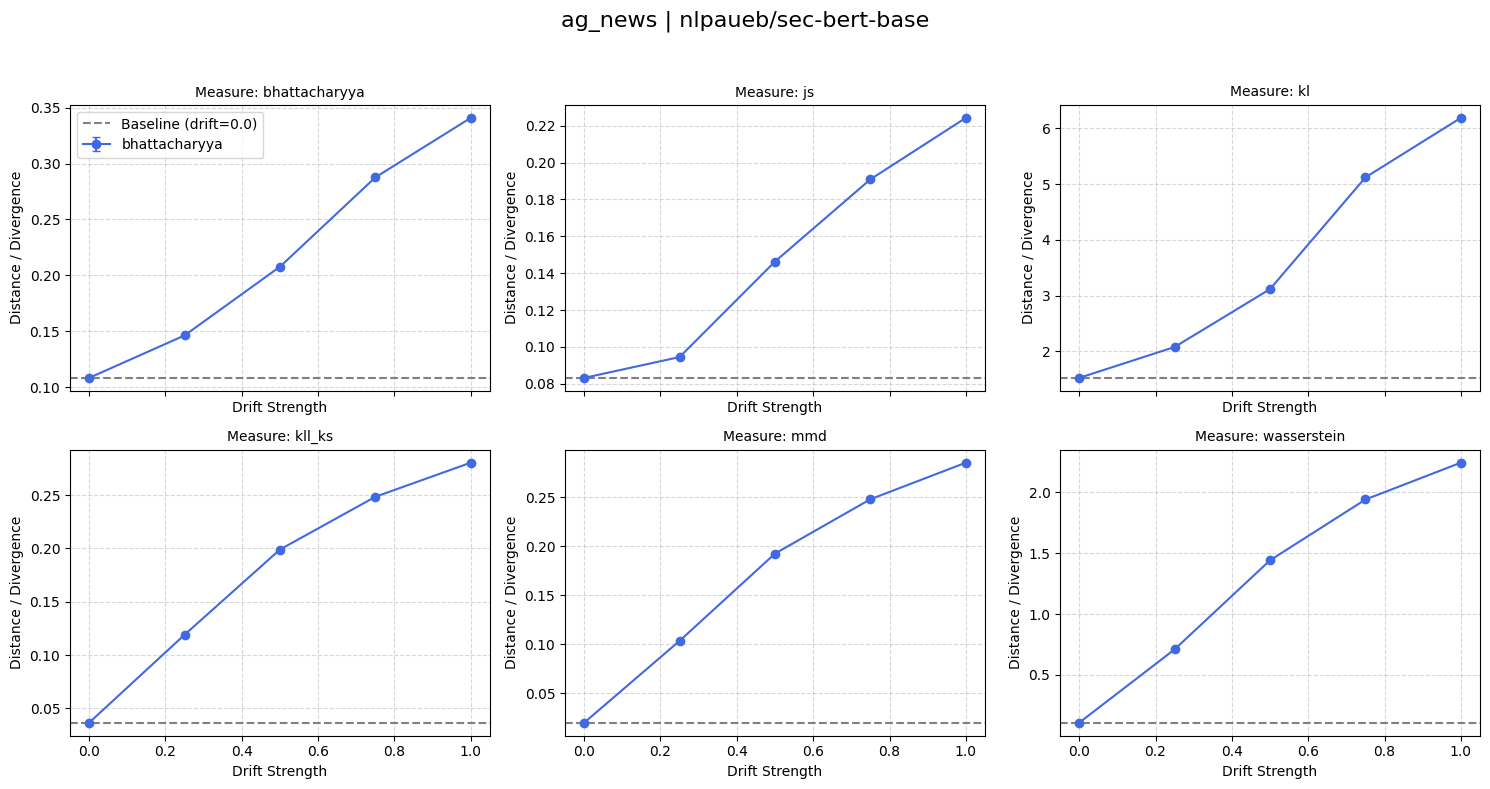

Saved figure: data-analysis/data/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


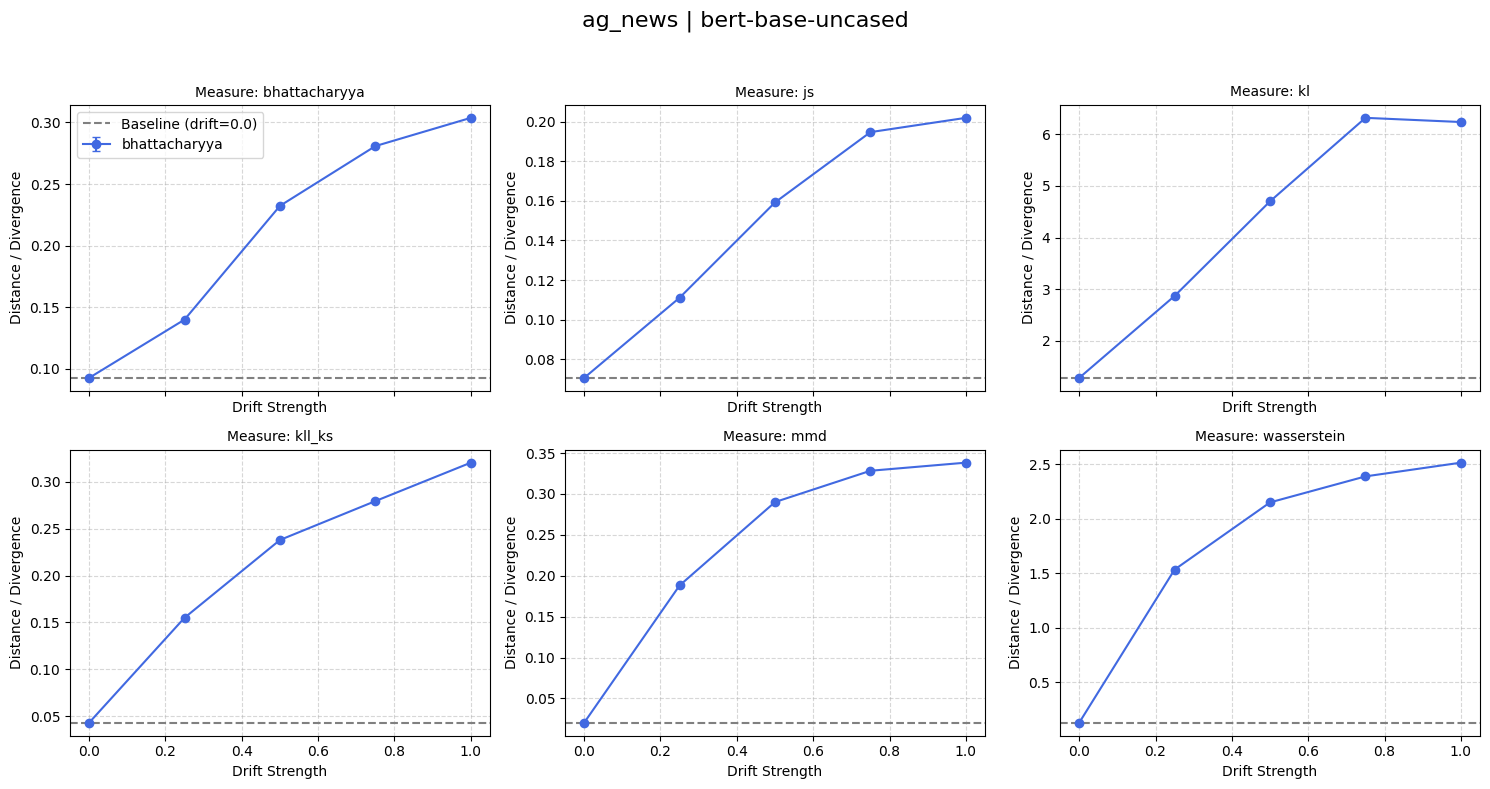

Saved figure: data-analysis/data/ag_news_bert-base-uncased_distribution_measures.png


In [13]:
###############################################################################
# 7) Plot with Error Bars (Updated)
###############################################################################
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_distribution_distances(all_results, args):
    """
    Plots distance metrics from `all_results`, which has keys of the form:
       (dataset_name, model_name, measure_name, drift_strength)
    and values that are lists of dictionaries like:
       [{"dist_val": ..., "time_taken": ..., "measure_overhead": ..., "seed": ...}, ...].

    We group by (dataset_name, model_name). For each measure, we plot:
       - error bars across drift_strength
       - where y-values are the mean of the distance values (dist_val)
       - and y-error is the standard deviation across seeds.

    The resulting figures are saved into args["output_dir"].

    Updates:
      - Draws a horizontal reference line for the baseline (drift=0.0).
      - Adds improved subplot labeling and grid usage.
    """
    # 1) Collect data into a structure for plotting
    #    plot_data[(dataset_name, model_name)][measure_name] = [(drift_strength, mean_val, std_val), ...]
    plot_data = defaultdict(lambda: defaultdict(list))

    for (dataset_name, model_name, measure_name, drift_strength), records in all_results.items():
        # records is a list of dicts, e.g. [{"dist_val": 0.1, "time_taken": 2.5, ...}, ...]
        # Extract just the dist_val for each seed
        dist_vals = [r["dist_val"] for r in records if r["dist_val"] is not None]

        if len(dist_vals) == 0:
            mean_val, std_val = 0.0, 0.0
        else:
            mean_val = np.mean(dist_vals)
            std_val  = np.std(dist_vals)

        plot_data[(dataset_name, model_name)][measure_name].append(
            (drift_strength, mean_val, std_val)
        )

    # 2) For each (dataset_name, model_name), produce subplots for each measure
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())  # e.g., ["kl", "js", "mmd", ...]
        n_measures = len(measure_names)

        # Arrange subplots in a grid
        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)
        axs = np.array(axs).flatten()  # flatten to iterate easily

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        # 3) Plot each measure in its own subplot
        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = measure_dict[measure_name]

            # Sort by drift_strength so the line is drawn in ascending order
            data_points.sort(key=lambda x: x[0])
            drift_strengths = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds  = [dp[2] for dp in data_points]

            # Plot with error bars
            ax.errorbar(
                drift_strengths,
                y_means,
                yerr=y_stds,
                fmt='-o',
                capsize=3,
                label=measure_name,
                color='royalblue'
            )
            ax.set_title(f"Measure: {measure_name}", fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle='--', alpha=0.5)

            # 3a) Draw a horizontal line at the baseline drift=0.0, if present
            baseline_points = [dp for dp in data_points if dp[0] == 0.0]
            if baseline_points:
                baseline_mean = baseline_points[0][1]  # mean_val for drift=0.0
                ax.axhline(
                    y=baseline_mean,
                    color='gray',
                    linestyle='--',
                    label="Baseline (drift=0.0)"
                )

            if i == 0:
                ax.legend()

        # Hide any unused subplots (if #measures < n_rows*n_cols)
        for j in range(len(measure_names), n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # 4) Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved figure: {save_path}")


# Finally, call the plot function with your results:
plot_distribution_distances(all_results, args)


In [14]:
import pandas as pd
import os

# Convert defaultdict to a structured DataFrame
rows = []
for (dataset, model, measure, drift_strength), records in all_results.items():
    # Extract the numeric 'dist_val' from each record
    for record in records:
        dist_val = record.get("dist_val")  # Safely get the distance value
        if dist_val is not None:
            rows.append([dataset, model, measure, drift_strength, dist_val])

# Create DataFrame
df = pd.DataFrame(rows, columns=["Dataset", "Model", "Measure", "Drift Strength", "Value"])

# Group by Dataset, Model, Measure, and Drift Strength, then compute mean and std
df_aggregated = df.groupby(["Dataset", "Model", "Measure", "Drift Strength"]).agg(
    Mean_Value=("Value", "mean"),
    Std_Value=("Value", "std")
).reset_index()

# Save to CSV
save_path = os.path.join(args["output_dir"], "all_results_distribution_aggregated.csv")
df_aggregated.to_csv(save_path, index=False)

print(f"Saved aggregated data to: {save_path}")

# Display the aggregated DataFrame
print(df_aggregated)


Saved aggregated data to: data-analysis/data/all_results_distribution_aggregated.csv
              Dataset                  Model        Measure  Drift Strength  \
0             ag_news      bert-base-uncased  bhattacharyya            0.00   
1             ag_news      bert-base-uncased  bhattacharyya            0.25   
2             ag_news      bert-base-uncased  bhattacharyya            0.50   
3             ag_news      bert-base-uncased  bhattacharyya            0.75   
4             ag_news      bert-base-uncased  bhattacharyya            1.00   
..                ...                    ...            ...             ...   
175  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.00   
176  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.25   
177  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.50   
178  yelp_review_full  nlpaueb/sec-bert-base    wasserstein            0.75   
179  yelp_review_full  nlpaueb/sec-bert-base  

In [15]:
def save_results_to_csv(all_results, args):
    """
    Save the results to a CSV file for further analysis.
    """
    summary_data = []

    # Aggregate results across all datasets and models
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        numeric_values = [v for v in values if isinstance(v, (int, float))]
        mean_val = np.mean(numeric_values)
        std_val = np.std(numeric_values)
        summary_data.append((dataset_name, model_name, measure_name, drift_strength, mean_val, std_val))

    # Convert to Pandas DataFrame
    df = pd.DataFrame(summary_data, columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std"])

    df.head()

    # Save to CSV for further analysis
    save_path = os.path.join(args["output_dir"], "all_results_distribution.csv")
    df.to_csv(save_path, index=False)
    print(f"Saved summary table to: {save_path}")

# Example usage
# save_results_to_csv(all_results, args)

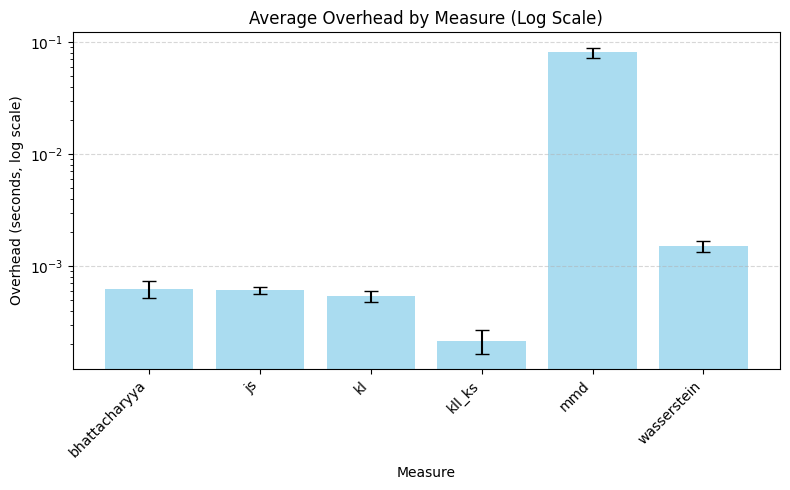

Saved results to: data-analysis/data-test/average_overhead_distribution.csv


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

def visualize_average_overhead_by_measure(all_results, output_csv_path):
    """
    Collapse across datasets, models, and drift_strength,
    and produce a bar chart of average overhead per measure (log scale).
    Save the results to a CSV file.
    """

    # 1) Convert 'all_results' into a pandas DataFrame
    rows = []
    for (dataset, model, measure, drift_strength), records in all_results.items():
        for rec in records:
            rows.append({
                "dataset": dataset,
                "model": model,
                "measure": measure,
                "drift_strength": drift_strength,
                "dist_val": rec["dist_val"],
                "time_taken": rec["time_taken"],
                "measure_overhead": rec["measure_overhead"],
                "seed": rec["seed"],
            })

    df = pd.DataFrame(rows)
    if df.empty:
        print("No results to visualize. DataFrame is empty.")
        return

    # 2) Group by just 'measure' (ignore dataset/model/drift_strength)
    #    and compute mean & std for measure_overhead
    grouped = (
        df.groupby("measure")["measure_overhead"]
        .agg(["mean", "std"])
        .reset_index()
        .rename(columns={"mean": "overhead_mean", "std": "overhead_std"})
    )

    # 3) Create a bar plot (with error bars) for overhead per measure
    plt.figure(figsize=(8, 5))

    # X positions for each measure on the bar chart
    x_positions = range(len(grouped))

    # Bar chart
    plt.bar(
        x_positions,
        grouped["overhead_mean"],
        yerr=grouped["overhead_std"],
        capsize=5,
        alpha=0.7,
        color="skyblue"
    )

    # Apply log scale
    plt.yscale("log")  # <-- LOG SCALE applied

    # Label the x-axis with measure names
    plt.xticks(ticks=x_positions, labels=grouped["measure"], rotation=45, ha="right")

    plt.title("Average Overhead by Measure (Log Scale)")
    plt.xlabel("Measure")
    plt.ylabel("Overhead (seconds, log scale)")
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

    # Save the grouped DataFrame to a CSV file
    grouped.to_csv(output_csv_path, index=False)
    print(f"Saved results to: {output_csv_path}")

    return grouped

# Example usage:
output_csv_path = "data-analysis/data-test/average_overhead_distribution.csv"
grouped_df = visualize_average_overhead_by_measure(all_results, output_csv_path)